In [1]:
import os
import time
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.ops import deform_conv2d
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt  # <--- NEW IMPORT

# ==========================================
#               CONFIGURATION
# ==========================================
CONFIG = {
    'model_name': 'eva02_tiny_patch14_224.mim_in22k',
    'img_size': 224,
    'batch_size': 32,
    'epochs': 50,
    'lr': 5e-5,
    'weight_decay': 0.01,
    'patience': 6,
    'num_classes': 4,          # Figshare: Glioma, Meningioma, Pituitary
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'data_dir': 'BTMK/', 
    'pretrained_path': 'hybrid_eva02_dcnn_best.pth', # Phase 1 Model
    'save_path': 'figshare_finetuned_best.pth',
    'plot_path': 'training_graph.png',               # <--- Graph Output File
    'seed': 42,
}

# ==========================================
#           1. DATA & UTILS
# ==========================================
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

def get_dataloaders(data_dir):
    transform = transforms.Compose([
        transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dir = os.path.join(data_dir, 'train')
    val_dir = os.path.join(data_dir, 'val')

    if not os.path.exists(train_dir):
        print(f"ERROR: Training folder not found at {train_dir}")
        exit()

    train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
    val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)
    
    print(f"Figshare Classes: {train_dataset.classes}")
    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
    return train_loader, val_loader

def save_plots(train_acc, val_acc, train_loss, val_loss):
    """
    Saves the accuracy and loss plots to a single image file.
    """
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, 'b-', label='Training Acc')
    plt.plot(epochs, val_acc, 'r-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(CONFIG['plot_path'])
    print(f"Graph saved to {CONFIG['plot_path']}")
    plt.close()

# ==========================================
#      2. MODEL DEFINITIONS
# ==========================================

class LocalCNNBranch(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, out_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_dim), nn.SiLU()
        )
    def forward(self, x): return self.net(x)

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, num_heads=4, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.q_proj = nn.Linear(dim, dim, bias=qkv_bias)
        self.k_proj = nn.Linear(dim, dim, bias=qkv_bias)
        self.v_proj = nn.Linear(dim, dim, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x_local, x_global):
        B, C, H, W = x_local.shape
        x_local_flat = x_local.flatten(2).transpose(1, 2)
        B_v, N_vit, C_v = x_global.shape
        
        q = self.q_proj(x_local_flat).reshape(B, H*W, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        k = self.k_proj(x_global).reshape(B, N_vit, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        v = self.v_proj(x_global).reshape(B, N_vit, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        
        x = (attn @ v).transpose(1, 2).reshape(B, H*W, C)
        x = self.proj(x)
        x = self.norm(x + x_local_flat)
        return x.transpose(1, 2).reshape(B, C, H, W)

class DeformableDCNNHead(nn.Module):
    def __init__(self, dim, num_classes):
        super().__init__()
        self.offset_conv = nn.Conv2d(dim, 2 * 3 * 3, kernel_size=3, padding=1)
        self.deform_weight = nn.Parameter(torch.Tensor(dim, dim, 3, 3))
        nn.init.kaiming_uniform_(self.deform_weight, nonlinearity='relu')
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(dim, num_classes)

    def forward(self, x):
        offsets = self.offset_conv(x)
        x = deform_conv2d(x, offsets, self.deform_weight, padding=1)
        x = self.act(self.bn(x))
        x = self.global_pool(x).flatten(1)
        return self.classifier(x)

class HybridEva02_DCNN(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.embed_dim = self.vit.num_features
        self.cnn = LocalCNNBranch(out_dim=self.embed_dim)
        self.fusion = CrossAttentionFusion(dim=self.embed_dim)
        self.head = DeformableDCNNHead(dim=self.embed_dim, num_classes=num_classes)

    def forward(self, x):
        x_vit = self.vit.forward_features(x)[:, 1:, :]
        x_cnn = self.cnn(x)
        x_fused = self.fusion(x_local=x_cnn, x_global=x_vit)
        return self.head(x_fused)

# ==========================================
#      3. WEIGHT LOADING
# ==========================================
def load_pretrained_weights(model, checkpoint_path):
    print(f"Loading weights from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=CONFIG['device'])
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
    model_dict = model.state_dict()
    pretrained_dict = {k: v for k, v in state_dict.items() if k in model_dict and 'head.classifier' not in k}
    model_dict.update(pretrained_dict) 
    model.load_state_dict(model_dict)
    print(f"Weights loaded. Head layer reset for new classes.")

# ==========================================
#      4. FINE-TUNING LOOP WITH GRAPH
# ==========================================
def finetune_engine():
    seed_everything(CONFIG['seed'])
    
    print("--- Phase 2: Fine-Tuning on Figshare ---")
    train_loader, val_loader = get_dataloaders(CONFIG['data_dir'])
    
    model = HybridEva02_DCNN(CONFIG['model_name'], CONFIG['num_classes']).to(CONFIG['device'])
    load_pretrained_weights(model, CONFIG['pretrained_path'])
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    
    best_acc = 0.0
    
    # --- HISTORY LISTS ---
    train_acc_history = []
    val_acc_history = []
    train_loss_history = []
    val_loss_history = []
    
    for epoch in range(CONFIG['epochs']):
        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Fine-tune]")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            # Accurate Loss accumulation
            running_loss += loss.item() * inputs.size(0) 
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({'loss': loss.item(), 'acc': correct/total})
            
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        
        # --- VALIDATION ---
        model.eval()
        val_correct = 0
        val_total = 0
        val_running_loss = 0.0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        
        print(f"Epoch {epoch+1} Result: Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")
        
        # --- UPDATE HISTORY ---
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        
        scheduler.step(val_acc)
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), CONFIG['save_path'])
            print(f"--> Best Figshare Model Saved! ({best_acc:.4f})")
            
    print(f"\nFine-Tuning Complete. Best Accuracy: {best_acc:.4f}")
    
    # --- SAVE PLOTS ---
    save_plots(train_acc_history, val_acc_history, train_loss_history, val_loss_history)

if __name__ == "__main__":
    finetune_engine()

--- Phase 2: Fine-Tuning on Figshare ---
Figshare Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 4914 | Val: 1052
Loading weights from hybrid_eva02_dcnn_best.pth...
Weights loaded. Head layer reset for new classes.


Epoch 1/50 [Fine-tune]: 100%|██████████| 154/154 [00:37<00:00,  4.15it/s, loss=0.244, acc=0.936] 


Epoch 1 Result: Train Acc: 0.9357 | Val Acc: 0.9506 | Val Loss: 0.1747
--> Best Figshare Model Saved! (0.9506)


Epoch 2/50 [Fine-tune]: 100%|██████████| 154/154 [00:35<00:00,  4.30it/s, loss=0.0224, acc=0.984]


Epoch 2 Result: Train Acc: 0.9839 | Val Acc: 0.9686 | Val Loss: 0.1159
--> Best Figshare Model Saved! (0.9686)


...

Epoch 48 Result: Train Acc: 1.0000 | Val Acc: 0.9848 | Val Loss: 0.1125


Epoch 49/50 [Fine-tune]: 100%|██████████| 154/154 [00:50<00:00,  3.04it/s, loss=0.00415, acc=1] 


Epoch 49 Result: Train Acc: 1.0000 | Val Acc: 0.9848 | Val Loss: 0.1110


Epoch 50/50 [Fine-tune]: 100%|██████████| 154/154 [00:36<00:00,  4.17it/s, loss=0.000764, acc=1]


Epoch 50 Result: Train Acc: 1.0000 | Val Acc: 0.9848 | Val Loss: 0.1134

Fine-Tuning Complete. Best Accuracy: 0.9886
Graph saved to training_graph.png


Test Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test Images:  1057

Running Test Evaluation...

 Test Accuracy : 0.9868
 Test Loss     : 0.0820

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       244
  meningioma       0.98      0.98      0.98       248
     notumor       0.99      1.00      0.99       300
   pituitary       1.00      0.98      0.99       265

    accuracy                           0.99      1057
   macro avg       0.99      0.99      0.99      1057
weighted avg       0.99      0.99      0.99      1057


Confusion Matrix:
[[241   3   0   0]
 [  2 242   3   1]
 [  0   0 300   0]
 [  1   3   1 260]]


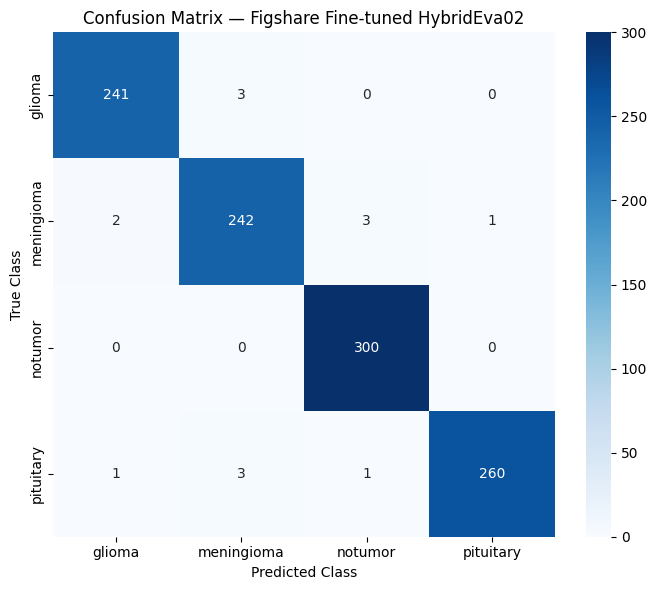

In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------
# Test Data Loader
# --------------------------------------
def get_test_loader(test_dir, img_size=224, batch_size=32):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    
    test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Test Classes: {test_dataset.classes}")
    print(f"Test Images:  {len(test_dataset)}")
    return test_loader, test_dataset.classes


# --------------------------------------
# Test Script Using Your Hybrid Model
# --------------------------------------
def test_figshare_model():
    device = CONFIG["device"]

    # Load Test Data
    test_dir = os.path.join(CONFIG["data_dir"], "test")
    test_loader, class_names = get_test_loader(test_dir, CONFIG["img_size"], CONFIG["batch_size"])

    # Load Model
    model = HybridEva02_DCNN(CONFIG['model_name'], CONFIG['num_classes'])
    model.load_state_dict(torch.load(CONFIG["save_path"], map_location=device))
    model.to(device)
    model.eval()

    criterion = nn.CrossEntropyLoss()

    total = 0
    correct = 0
    total_loss = 0.0

    all_labels = []
    all_preds = []

    print("\nRunning Test Evaluation...")

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    # Final Metrics
    test_acc = correct / total
    avg_loss = total_loss / len(test_loader)

    print("\n====================================")
    print(f" Test Accuracy : {test_acc:.4f}")
    print(f" Test Loss     : {avg_loss:.4f}")
    print("====================================\n")

    # Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nConfusion Matrix:")
    print(cm)

    # --------------------------------------
    # BEAUTIFUL SEABORN CONFUSION MATRIX
    # --------------------------------------
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title("Confusion Matrix — Figshare Fine-tuned HybridEva02")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.tight_layout()
    plt.show()


# Run Test
test_figshare_model()
